<div style="text-align: center; font-weight: bold; font-size: 150%">Projet 3 - Grad-CAM (Class Activation Map)</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Stéphane CHRETIEN</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>

Ce travail se base sur le notebook [ici](https://colab.research.google.com/drive/1EncgCmj2meBTGLAyrsIm6CBhYQsAWTI-?usp=sharing).

<div style="text-align: center; font-weight: bold; font-size: 125%">1. Méthode Grad-CAM</div><br>

Le Grad-CAM est une méthode d'interprétation de modèle, qu'on utilise sur les CNN afin de comprendre quelle partie d'une image influence sa prédiction. 

Pour implémenter cette méthode les étapes à suivre sont les suivantes: 

- Récupération de la sortie de la dernière couche de convolution.
- Application d'une loss sur le filtre.
- Application d'un "Gradient Ascent" qui active au maximum le filtre.(Cela permet de déterminer ce que ce filtre arrive à détecter dans l'image)
- Superposition du heatmap obtenu sur l'image afin de déterminer ce que le modèle voit sur l'image avant de prédire.

<div style="text-align: center; font-weight: bold; font-size: 125%">2.Étude de cas du notebook original : Image du lapin </div><br>

<div style="text-align: center; font-weight: bold; font-size: 100%">2.1. Modélisation</div><br>

In [21]:
# Usual Imports for Deep Learning
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Display
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm


Le modèle utilisé est le modèle préentrainé Xception (doc ici: https://keras.io/api/applications/xception/).

In [22]:
# Prepare the model. model_builder() is used to load Xception with Keras
# You can check the documentation of those functions on https://www.tensorflow.org
model_builder = keras.applications.xception.Xception
img_size = (299, 299)
preprocess_input = keras.applications.xception.preprocess_input
decode_predictions = keras.applications.xception.decode_predictions


# Create the model, by using pretrained weights on ImageNet
model = model_builder(weights="imagenet")
print(model.summary())

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_5[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 22,910,480 (87.40 MB)

 Trainable params: 22,855,952 (87.19 MB)

 Non-trainable params: 54,528 (213.00 KB)

None


Après avoir construit le modèle, on récupère la dernière couche de convolution du modèle et l'image qui va nous servir d'exemple.

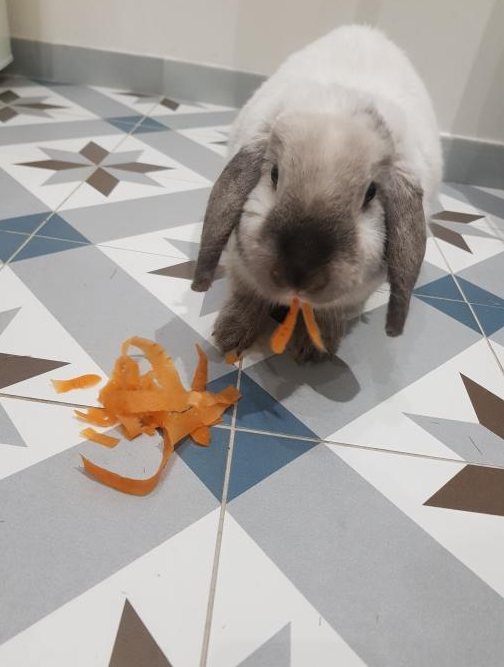

In [23]:
# Isolate the last convolutional layer
last_conv_layer_name = "block14_sepconv2_act"
classifier_layer_names = [
    "avg_pool",
    "predictions",
]

# The local path to our target image
#img_path = keras.utils.get_file( "rabbit.jpg", "https://i.imgur.com/vH1MxgA.png")

img_path = "images/rabbit.png"

# Visualize the image
display(Image(img_path))

<div style="text-align: center; font-weight: bold; font-size: 100%">2.2. L'algorithme Grad-CAM</div><br>

In [24]:
#### Functions to compute Grad-CAM
def get_img_array(img_path, size):
    # `img` is a PIL image of size 299x299
    img = keras.preprocessing.image.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3). We do this because this dimension is needed for most built-in functions
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, classifier_layer_names, prediction_rank=1):
    # The variable "prediction_rank" is used to apply gradcam on the top class
    # You can modify it to prediction_rank=n for a heatmap on the nth top class

    # First, we create a model that maps the input image to the activations of the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

    # Second, we create a model that maps the activations of the last conv layer to the final class predictions
    classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer_name in classifier_layer_names:
        x = model.get_layer(layer_name)(x)
    classifier_model = keras.Model(classifier_input, x)

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        # GradientTape() is a built-in Tensorflow tool to record operations for automatic differentiation.
        # https://www.tensorflow.org/api_docs/python/tf/GradientTape
        # We compute activations of the last conv layer and make the tape watch it
        last_conv_layer_output = last_conv_layer_model(img_array)
        tape.watch(last_conv_layer_output)
        # Compute class predictions
        # We pass the activations of the last conv in our classifier_model to obtain the predictions of the model
        preds = classifier_model(last_conv_layer_output)
        # This prediction has a shape=(1, 1000) because there is 1000 classes in ImageNet.
        # We find the index of the top prediction and we call it pred_index, because it's the index of the prediction
        pred_index = tf.argsort(preds)[0][-prediction_rank]
        # We only keep the value of the prediction at the position of the pred_index
        top_class_channel = preds[:, pred_index]


    # This is the gradient of the top predicted class with respect to
    # the output feature map of the last conv layer
    grads = tape.gradient(top_class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with respect to the top predicted class
    last_conv_layer_output = last_conv_layer_output.numpy()[0]
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]

    # The channel-wise mean of the resulting feature map
    # is our heatmap of activation for the top class
    heatmap = np.mean(last_conv_layer_output, axis=-1)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Top 1 Prediction: [('n02328150', 'Angora', 0.4097226)]
Top 3 Predictions: [('n02328150', 'Angora', 0.4097226), ('n02364673', 'guinea_pig', 0.070129775), ('n02325366', 'wood_rabbit', 0.064927325)]


/Users/yayraleakibode/Documents/Master_MALIA/DataSciencePortfolio/xai/venv_py_3.9/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_146']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


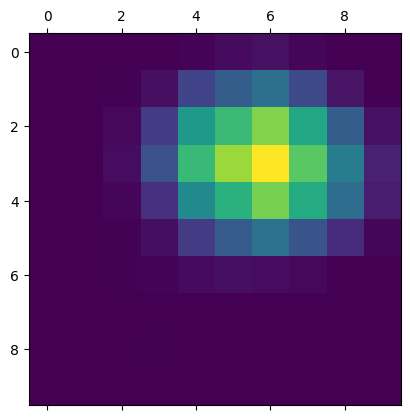

In [25]:
#### Apply Grad-CAM to our image and display the resulting heatmap
# Prepare image
img_array = preprocess_input(get_img_array(img_path, size=img_size))

# Print what the top predicted class is (Angora stands for Angora Rabbit in ImageNet labels)
# According to https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/decode_predictions
# decode_predictions() returns a list of lists of top class prediction tuples (class_name, class_description, score)
# class_name is the internal name of the class, class_description the name in natural language and score is the probability of this prediction.
# top=1 is used to have the top class and [0] to have the first element of the list.
preds = model.predict(img_array)
print("Top 1 Prediction:", decode_predictions(preds, top=1)[0])

# In order to check the 2nd and 3rd predicted class, we also print the predictions with top=3
print("Top 3 Predictions:", decode_predictions(preds, top=3)[0])

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, classifier_layer_names
)

# Display heatmap. This heatmap is normalized for visualisation purpose, as explained in make_gradcam_heatmap()
# Thanks to that, we can know what part of the image was the most important to predict the top class
plt.matshow(heatmap)
plt.show()

Le heatmap à lui seul ne donne pas une grande interprétation (abstraite). Il faut donc la superposer à l'image pour pouvoir tirer des conclusions.

/var/folders/sn/pv9cpxsd4kz9qyrpf0zz4q3w0000gn/T/ipykernel_63975/1195055133.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


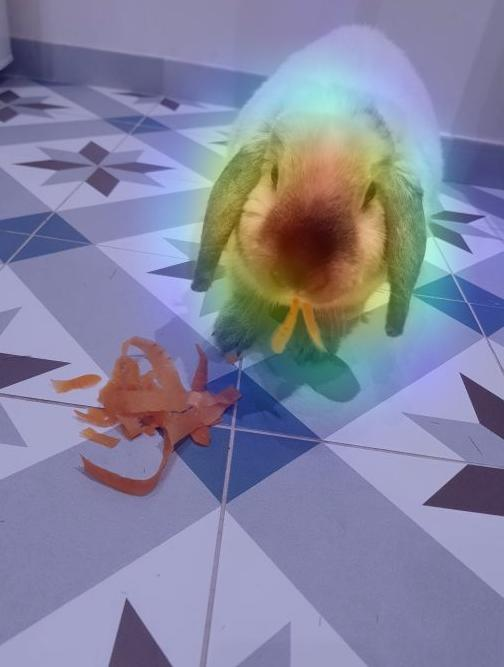

In [26]:
#### Superimpose the heatmap on original image
# We load the original image
img = keras.preprocessing.image.load_img(img_path)
img = keras.preprocessing.image.img_to_array(img)

# We rescale heatmap to a range 0-255 (because earlier, for visualization purpose, we normalized the heatmap between 0 & 1)
# We rescale it on this range to have it in RGB, so that we can superimpose it on the rabbit picture.
heatmap = np.uint8(255 * heatmap)

# We use jet colormap to colorize heatmap
jet = cm.get_cmap("jet")

# We use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# We create an image with RGB colorized heatmap
jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * 0.4 + img #0.4 good value
superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

# Save the superimposed image
save_path = "images/rabbit_cam.jpg"
superimposed_img.save(save_path)

# Display Grad CAM
display(Image(save_path))

**Conclusion 1 :** 

Le modèle s'est basé sur la tête du lapin pour pouvoir prédire que c'est un lapin. Ce qui prend tout son sens. Car en effet, il aurait pu se baser sur la carotte au sol pour prédire que c'était un lapin. 

<div style="text-align: center; font-weight: bold; font-size: 125%">3. Étude de cas: Image d'un léopard caché dans un buisson de la même couleur</div><br>

Pour cette expérience, nous avons choisi une image où le léopard se fond dans le buisson. Nous voulons tester si le modèle arrive à voir le léopard.

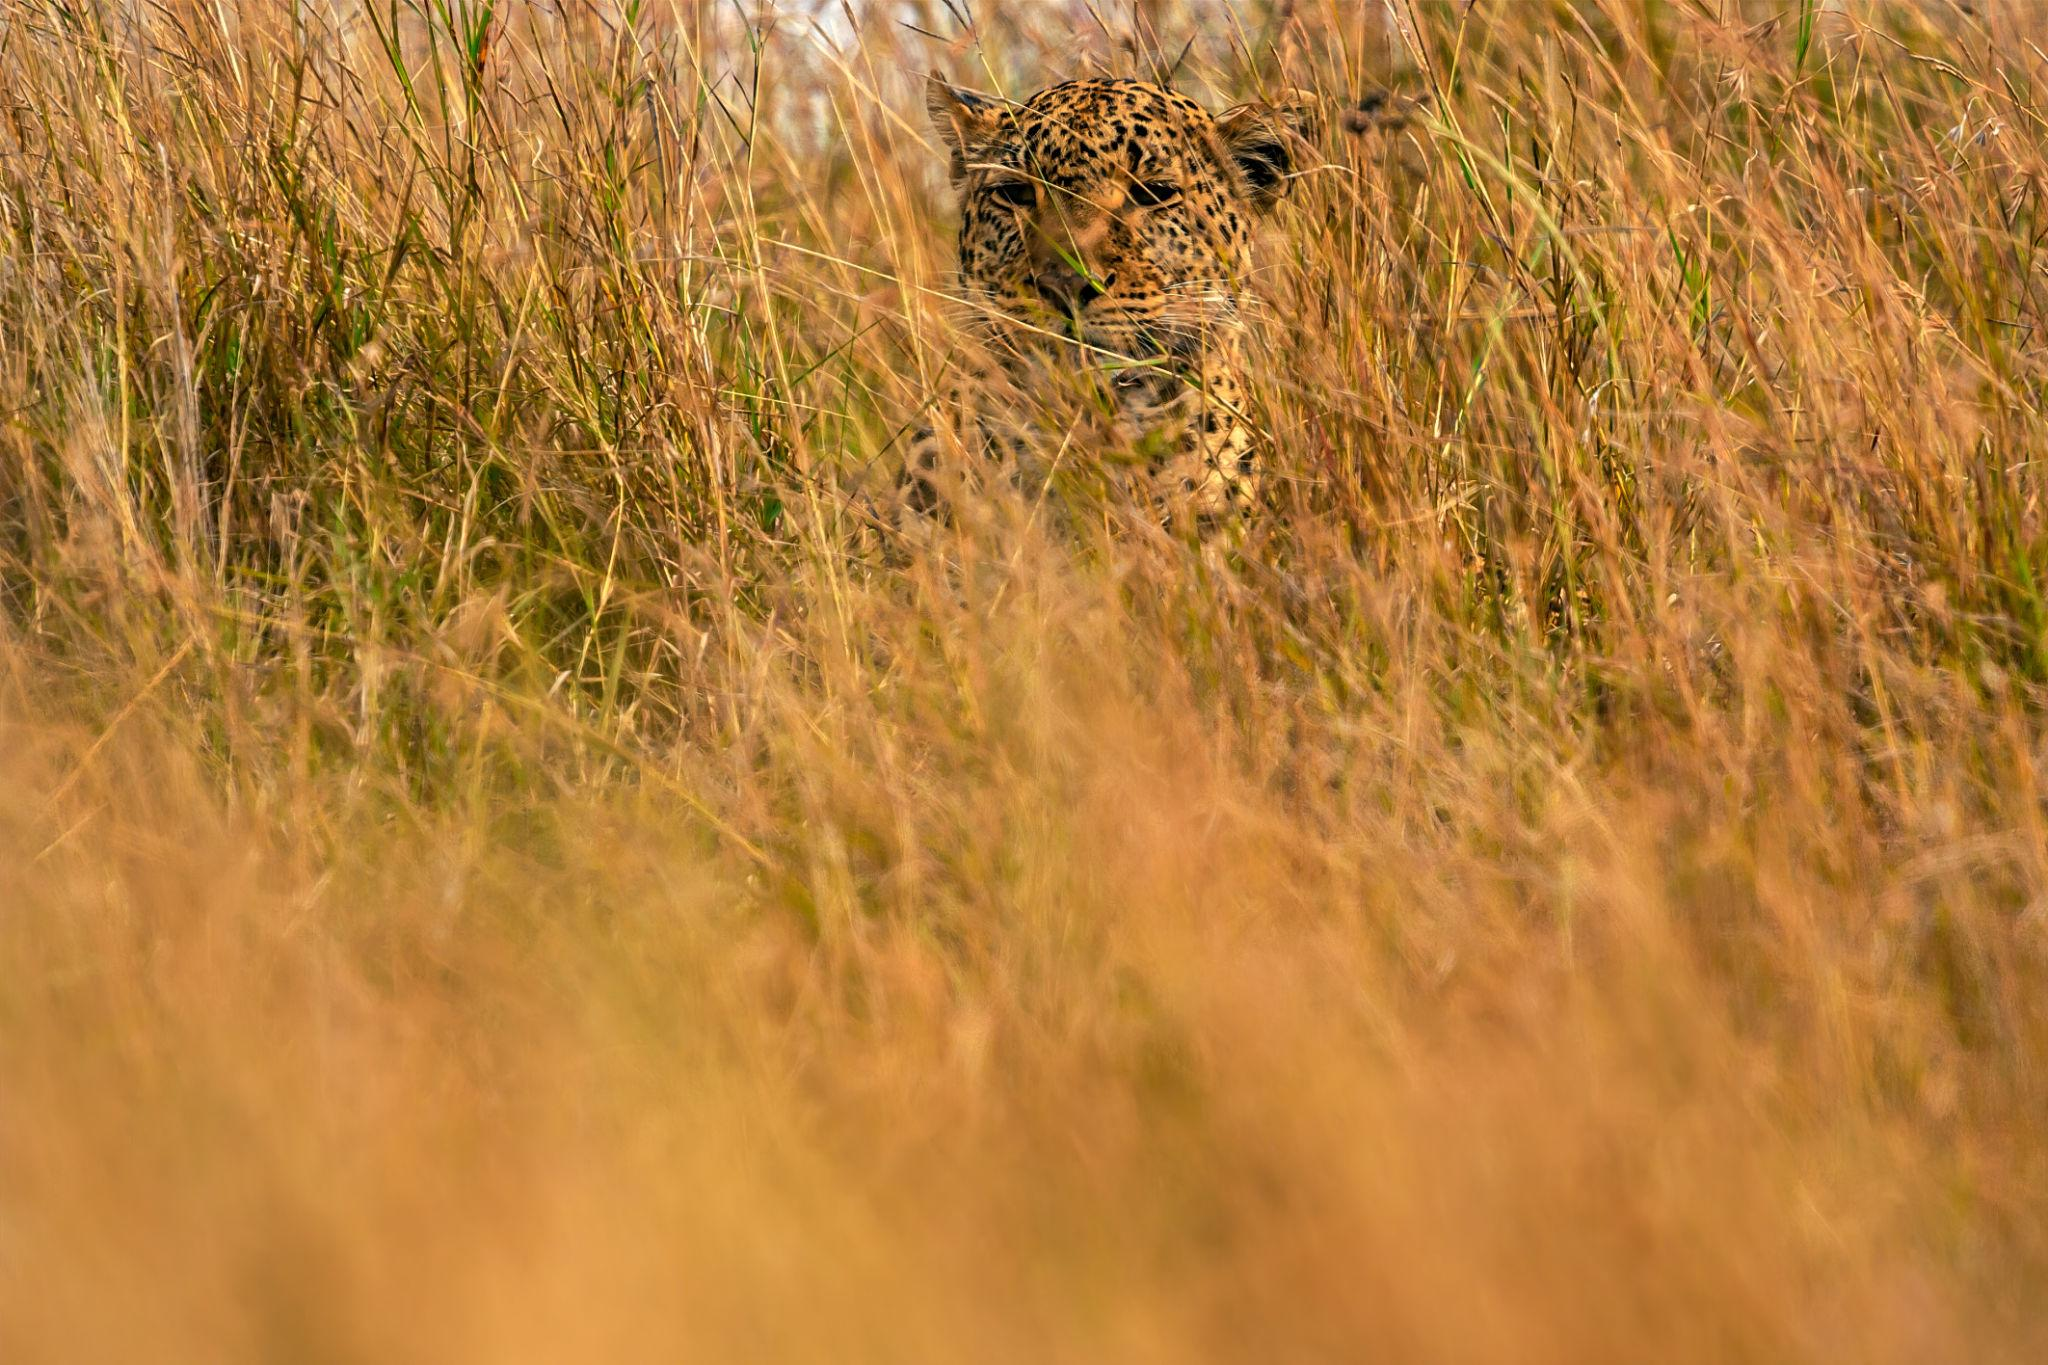

In [27]:
####Loading the image 
img_path = "images/leopard.jpeg"

# Visualize the image
display(Image(img_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Top 1 Prediction: [('n02018795', 'bustard', 0.5169916)]
Top 3 Predictions: [('n02018795', 'bustard', 0.5169916), ('n02114855', 'coyote', 0.1386896), ('n02130308', 'cheetah', 0.08032291)]


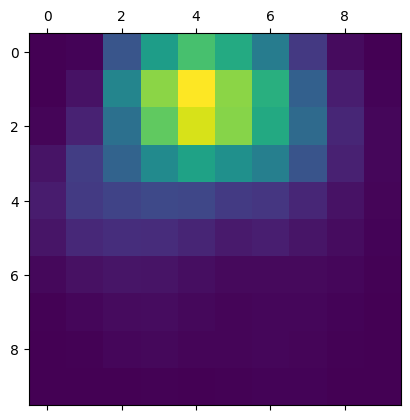

In [28]:
####Applying Grad-CAM to our image and display the resulting heatmap
# Prepare image
img_array = preprocess_input(get_img_array(img_path, size=img_size))

# Print what the top predicted class is (Angora stands for Angora Rabbit in ImageNet labels)
# According to https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/decode_predictions
# decode_predictions() returns a list of lists of top class prediction tuples (class_name, class_description, score)
# class_name is the internal name of the class, class_description the name in natural language and score is the probability of this prediction.
# top=1 is used to have the top class and [0] to have the first element of the list.
preds = model.predict(img_array)
print("Top 1 Prediction:", decode_predictions(preds, top=1)[0])

# In order to check the 2nd and 3rd predicted class, we also print the predictions with top=3
print("Top 3 Predictions:", decode_predictions(preds, top=3)[0])

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, classifier_layer_names
)

# Display heatmap. This heatmap is normalized for visualisation purpose, as explained in make_gradcam_heatmap()
# Thanks to that, we can know what part of the image was the most important to predict the top class
plt.matshow(heatmap)
plt.show()

/var/folders/sn/pv9cpxsd4kz9qyrpf0zz4q3w0000gn/T/ipykernel_63975/2194453160.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


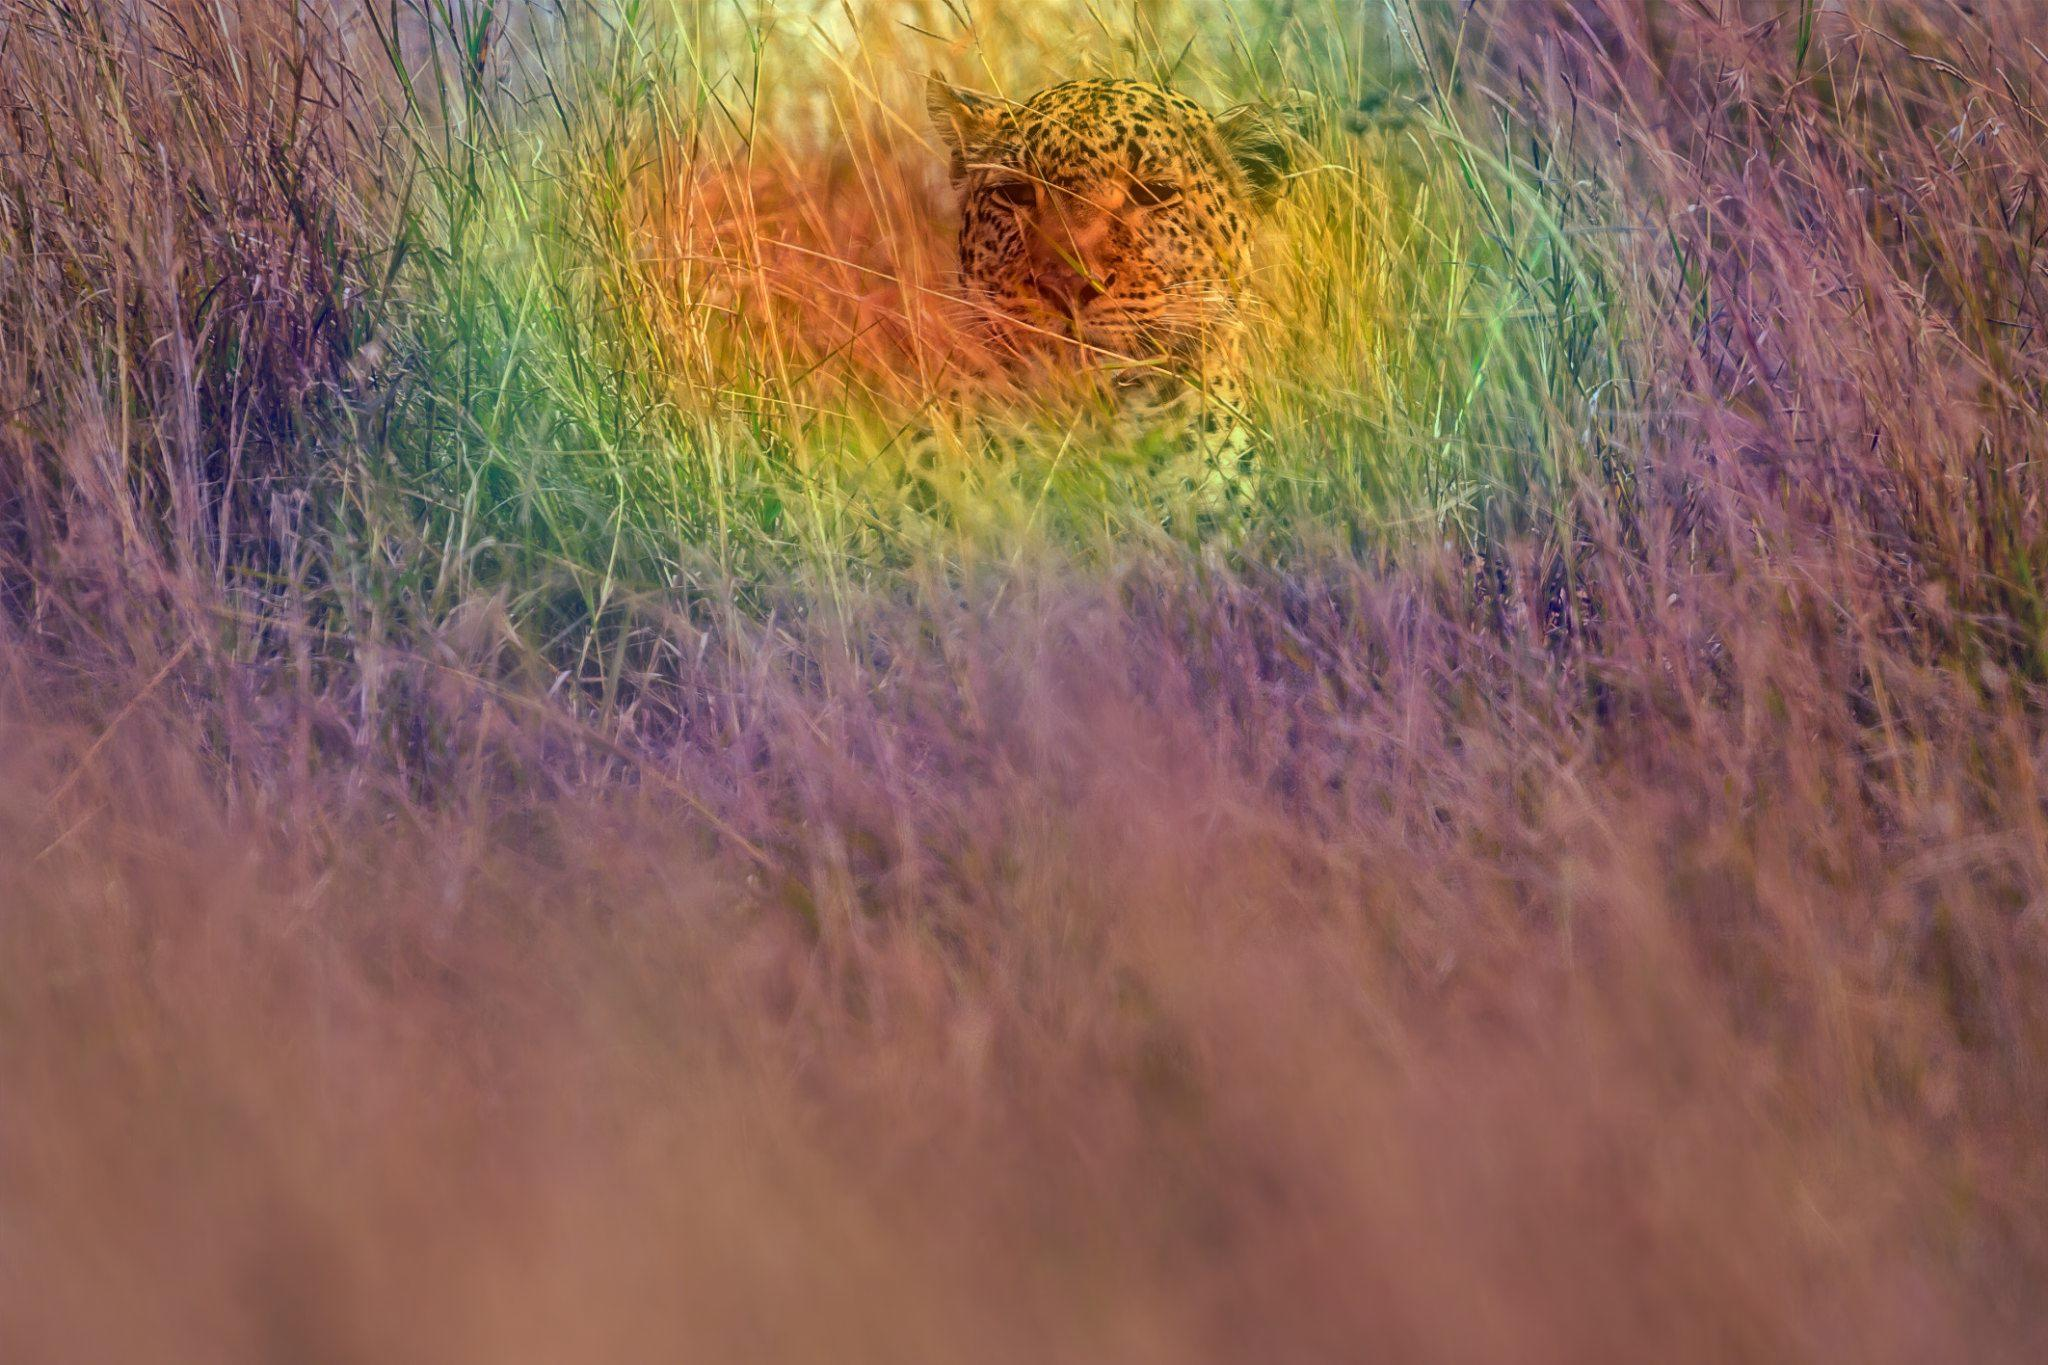

In [29]:
####Superimpose the heatmap on original image
img = keras.preprocessing.image.load_img(img_path)
img = keras.preprocessing.image.img_to_array(img)

# We rescale heatmap to a range 0-255 (because earlier, for visualization purpose, we normalized the heatmap between 0 & 1)
# We rescale it on this range to have it in RGB, so that we can superimpose it on the rabbit picture.
heatmap = np.uint8(255 * heatmap)

# We use jet colormap to colorize heatmap
jet = cm.get_cmap("jet")

# We use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# We create an image with RGB colorized heatmap
jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * 0.4 + img #0.4 good value
superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

# Save the superimposed image
save_path = "images/leopard_cam.jpg"
superimposed_img.save(save_path)

# Display Grad CAM
display(Image(save_path))

**Conclusion 2 :** 

L'idée de cette section était de tester les limites de la méthode implémentée. Cependant, il est évident que le modèle arrive à bien détecter le léopard.

**Conclusion générale :** 

En somme, grâce au Grad-CAM, nous avons pu ouvrir la boîte noire que représente les modèles de deep learning. Et surtout il est intéressant de voir que le modèle se base sur les bonnes parties de l'image pour pouvoir faire des prédictiobns.